# S4 · Biosynthetic pathway against the activation clusters

The figures for section 7 of the main notebook: Cramér's V for the receptor clusters and for
the descriptor-only control against the permutation floor, where in the clusters each pathway
falls, and how concentrated each pathway is.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
MAIN_TABLES = Path("../Tables")     # written by ../figure2_activation_code.ipynb
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"

import matplotlib as mpl
from collections import Counter
from scipy.stats import chi2_contingency

In [2]:
data = ac.load_activation_data(PROBABILITIES, M2OR_PAIRS, FASTA)
smiles_by_odorant, tags_by_odorant = ac.odour_tags(M2OR_PAIRS, ODOURS, data.odorant_ids)
class_of = ac.receptor_classes(CLASSES)
print(f"density {data.fill.density:.4%}   cut {data.fill.cut:.4f} (an output of the fill)")

clustered_ids, clustered_matrix, labels = ac.cluster_odorants(data.hybrid, data.odorant_ids)
enrichment = ac.tag_enrichment(clustered_ids, labels, tags_by_odorant)
info, display_order = ac.name_clusters(enrichment, labels)
print("cluster sizes", [info[c]["size"] for c in display_order])

pathway_result = ac.pathway_association(clustered_ids, labels, smiles_by_odorant, ODOURS, PATHWAYS)
results = pathway_result["results"]
pathway = pathway_result["pathway"]
use = pathway_result["use"]
descriptor_labels = pathway_result["descriptor_labels"]
for name, result in results.items():
    print(f"{name:20s} Cramér V = {result['v']:.3f}   floor {result['floor']:.3f} (95th {result['floor95']:.3f})")

density 2.7453%   cut 0.8917 (an output of the fill)


cluster sizes [70, 100, 127, 214, 68, 108]


receptor clusters    Cramér V = 0.356   floor 0.107 (95th 0.137)
descriptor clusters  Cramér V = 0.569   floor 0.108 (95th 0.138)


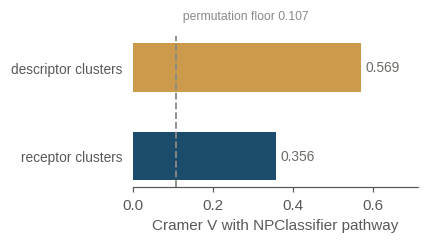

In [3]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0], FIGSIZE[1] * 0.8))
names = list(results)
values = [results[n]["v"] for n in names]
floor = results[names[0]]["floor"]
ax.barh(range(len(names)), values, color=["#083d5e", "#C8923B"], height=0.55, alpha=0.92)
ax.axvline(floor, ls="--", lw=1.2, color="#8a8a86")
ax.text(floor, len(names) - 0.35, f"  permutation floor {floor:.3f}", fontsize=8, color="#8a8a86", va="top")
for i, v in enumerate(values):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9, color="#6b6b67")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlim(0, max(values) * 1.25)
ax.set_xlabel("Cramer V with NPClassifier pathway", fontsize=10)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(FIGURES / "05_pathway_recovery.svg", bbox_inches="tight")
plt.show()

Clusters are labelled with their top enriched descriptors. Left, what each cluster is made
of; right, Pearson residuals, so warm is more odorants than independence predicts and blue is
fewer.

In [4]:
significant = ac.significant_enrichment(enrichment)
cluster_label = {}
for c in range(ac.N_CLUSTERS):
    top = significant[significant.cluster == c].sort_values("obs_exp", ascending=False).tag.head(3).tolist()
    cluster_label[c] = " / ".join(top) if top else "unnamed"
    print(f"  cluster {c}  n={int((labels == c).sum()):3d}   {cluster_label[c]}")

  cluster 0  n=127   floral
  cluster 1  n=214   cucumber / coconut / melon
  cluster 2  n= 70   acidic / sour / cheesy
  cluster 3  n=108   smoky / medicinal / phenolic
  cluster 4  n=100   hazelnut / warm / anisic
  cluster 5  n= 68   solvent / alcoholic / ethereal


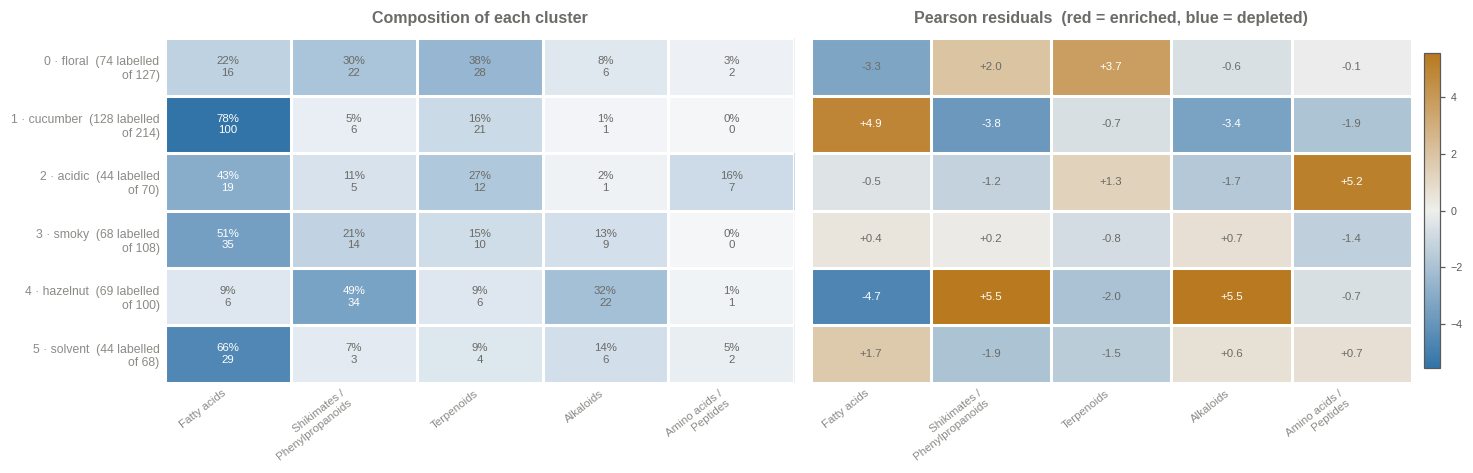

In [5]:
SEQ_HUE = "#3273a8"
POS, NEG = "#b8791f", "#3273a8"
INK, MUTED = "#6b6b67", "#8a8a86"

counts = results["receptor clusters"]["ct"]
order = counts.sum(0).sort_values(ascending=False).index      # pathways, commonest first
counts = counts[order]
composition = counts.div(counts.sum(1), axis=0) * 100
_, _, _, expected = chi2_contingency(counts)
residuals = (counts.values - expected) / np.sqrt(expected)

row_labels = [f"{c} · {cluster_label[c].split(' / ')[0]}  ({int(counts.iloc[c].sum())} labelled\nof "
              f"{int((labels == c).sum())})" for c in counts.index]
column_labels = [p.replace("Shikimates and Phenylpropanoids", "Shikimates /\nPhenylpropanoids")
                 .replace("Amino acids and Peptides", "Amino acids /\nPeptides") for p in order]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
ax = axes[0]
ax.imshow(composition.values, cmap=mpl.colors.LinearSegmentedColormap.from_list("seq", ["#f4f6f8", SEQ_HUE]),
          aspect="auto", vmin=0, vmax=composition.values.max())
for i in range(composition.shape[0]):
    for j in range(composition.shape[1]):
        v = composition.values[i, j]
        ax.text(j, i, f"{v:.0f}%\n{int(counts.values[i, j])}", ha="center", va="center", fontsize=7.5,
                color="white" if v > composition.values.max() * 0.55 else INK)
ax.set_title("Composition of each cluster", fontsize=10.5, fontweight="bold", color=INK, pad=10)

limit = np.abs(residuals).max()
ax = axes[1]
image = ax.imshow(residuals, cmap=mpl.colors.LinearSegmentedColormap.from_list("div", [NEG, "#eeeeec", POS]),
                  aspect="auto", vmin=-limit, vmax=limit)
for i in range(residuals.shape[0]):
    for j in range(residuals.shape[1]):
        ax.text(j, i, f"{residuals[i, j]:+.1f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(residuals[i, j]) > limit * 0.6 else INK)
ax.set_title("Pearson residuals  (red = enriched, blue = depleted)", fontsize=10.5, fontweight="bold", color=INK, pad=10)
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02).ax.tick_params(labelsize=7)

for k, ax in enumerate(axes):
    ax.set_xticks(range(len(column_labels)))
    ax.set_xticklabels(column_labels, fontsize=7.5, rotation=38, ha="right", color=MUTED)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels if k == 0 else [], fontsize=8, color=MUTED)
    ax.set_xticks(np.arange(-.5, len(column_labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "05_pathway_by_cluster.svg", bbox_inches="tight")
plt.show()

Left, both clusterings against 2,000 label permutations. Right, the share of each pathway
that lands in its single commonest cluster. That is descriptive: a pathway can look gathered
just by landing in a big cluster, which the residuals above correct for.

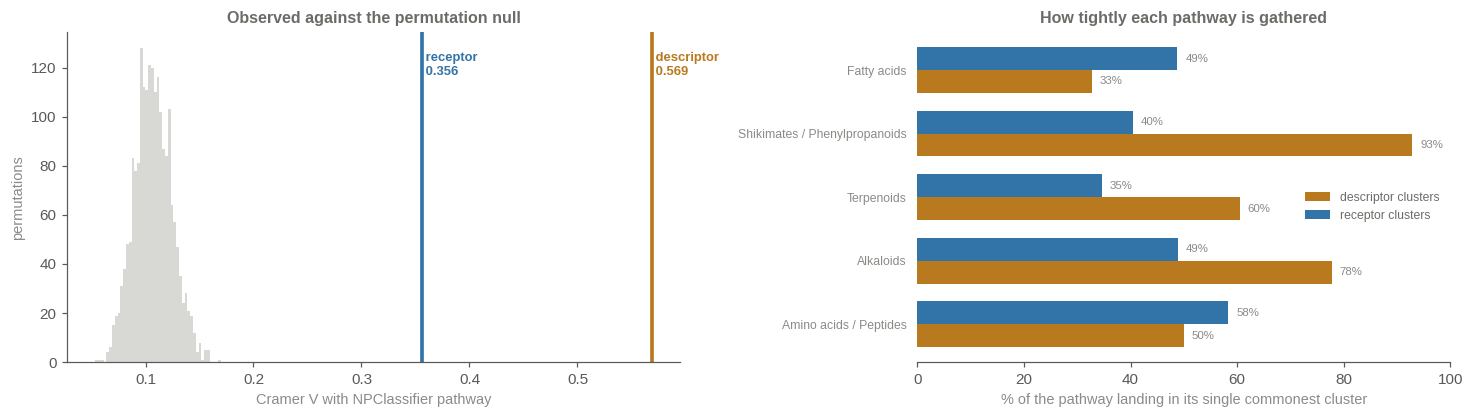

share in the commonest cluster (%)
  Fatty acids                        receptor  48.8   descriptor  32.7
  Shikimates and Phenylpropanoids    receptor  40.5   descriptor  92.9
  Terpenoids                         receptor  34.6   descriptor  60.5
  Alkaloids                          receptor  48.9   descriptor  77.8
  Amino acids and Peptides           receptor  58.3   descriptor  50.0


In [6]:
rng = np.random.default_rng(0)
null = {}
for name, cluster_labels in [("receptor clusters", labels), ("descriptor clusters", descriptor_labels)]:
    kept_labels = np.asarray(cluster_labels)[use]
    null[name] = np.array([ac.cramers_v(rng.permutation(kept_labels), pathway[use])[0] for _ in range(2000)])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ax.hist(null["receptor clusters"], bins=45, color="#d8d8d4", edgecolor="none", label="null (permuted)")
for name, colour in [("receptor clusters", NEG), ("descriptor clusters", POS)]:
    v = results[name]["v"]
    ax.axvline(v, color=colour, lw=2.4)
    ax.text(v, ax.get_ylim()[1] * 0.94, f" {name.split()[0]}\n {v:.3f}", fontsize=8.5, color=colour, va="top",
            fontweight="bold")
ax.set_xlabel("Cramer V with NPClassifier pathway", fontsize=9.5, color=MUTED)
ax.set_ylabel("permutations", fontsize=9.5, color=MUTED)
ax.set_title("Observed against the permutation null", fontsize=10.5, fontweight="bold", color=INK)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)


def concentration(cluster_labels):
    """% of each pathway's odorants that fall in its single commonest cluster."""
    shares = {}
    for p in order:
        selected = (pathway == p) & use
        if selected.sum() < 5:
            continue
        shares[p] = Counter(np.asarray(cluster_labels)[selected]).most_common(1)[0][1] / selected.sum() * 100
    return shares


receptor_share, descriptor_share = concentration(labels), concentration(descriptor_labels)
pathway_names = list(receptor_share)
ys = np.arange(len(pathway_names))
bar_height = 0.36
ax = axes[1]
ax.barh(ys + bar_height / 2, [descriptor_share[p] for p in pathway_names], height=bar_height, color=POS,
        label="descriptor clusters")
ax.barh(ys - bar_height / 2, [receptor_share[p] for p in pathway_names], height=bar_height, color=NEG,
        label="receptor clusters")
for i, p in enumerate(pathway_names):
    ax.text(descriptor_share[p] + 1.5, i + bar_height / 2, f"{descriptor_share[p]:.0f}%", va="center", fontsize=7.5,
            color=MUTED)
    ax.text(receptor_share[p] + 1.5, i - bar_height / 2, f"{receptor_share[p]:.0f}%", va="center", fontsize=7.5,
            color=MUTED)
ax.set_yticks(ys)
ax.set_yticklabels([p.replace(" and ", " / ") for p in pathway_names], fontsize=8, color=MUTED)
ax.set_xlabel("% of the pathway landing in its single commonest cluster", fontsize=9.5, color=MUTED)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 0.55), labelcolor=INK)
ax.set_title("How tightly each pathway is gathered", fontsize=10.5, fontweight="bold", color=INK)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(FIGURES / "05_pathway_null_and_concentration.svg", bbox_inches="tight")
plt.show()

print("share in the commonest cluster (%)")
for p in pathway_names:
    print(f"  {p:34s} receptor {receptor_share[p]:5.1f}   descriptor {descriptor_share[p]:5.1f}")

Notes:
- NPClassifier infers pathway from structure, and the activation profiles are predicted from
  structure, so part of any association is two structure-derived labels agreeing.
- Fatty acids are 205 of the 427 odorants analysed.
- Joined on the full InChIKey against COCONUT release 08-2026; 202 more odorants match only
  at the skeleton level (a different stereoisomer in COCONUT) and are left out.